<a href="https://colab.research.google.com/github/av1ary/Python-Projects/blob/main/Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# START

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from matplotlib import gridspec

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.6f}'.format
# to avoid scientific notation

In [ ]:
path = kagglehub.competition_download('home-credit-default-risk')

print("Path to dataset files:", path)
# to download you need to have kaggle account

100%|██████████| 688M/688M [00:03<00:00, 206MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/competitions/home-credit-default-risk


In [ ]:
train = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/application_train.csv")
train.head()
# main train split of the competition, it is already cut

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000000,406597.500000,24700.500000,351000.000000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.000000,-2120,NaN,1,1,0,1,1,0,Laborers,1.000000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.024700,0.036900,0.972200,0.619200,0.014300,0.000000,0.069000,0.083300,0.125000,0.036900,0.020200,0.019000,0.000000,0.000000,0.025200,0.038300,0.972200,0.634100,0.014400,0.000000,0.069000,0.083300,0.125000,0.037700,0.022000,0.019800,0.000000,0.000000,0.025000,0.036900,0.972200,0.624300,0.014400,0.000000,0.069000,0.083300,0.125000,0.037500,0.020500,0.019300,0.000000,0.000000,reg oper account,block of flats,0.014900,"Stone, brick",No,2.000000,2.000000,2.000000,2.000000,-1134.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
1,100003,0,Cash loans,F,N,N,0,270000.000000,1293502.500000,35698.500000,1129500.000000,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.000000,-291,NaN,1,1,0,1,1,0,Core staff,2.000000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.095900,0.052900,0.985100,0.796000,0.060500,0.080000,0.034500,0.291700,0.333300,0.013000,0.077300,0.054900,0.003900,0.009800,0.092400,0.053800,0.985100,0.804000,0.049700,0.080600,0.034500,0.291700,0.333300,0.012800,0.079000,0.055400,0.000000,0.000000,0.096800,0.052900,0.985100,0.798700,0.060800,0.080000,0.034500,0.291700,0.333300,0.013200,0.078700,0.055800,0.003900,0.010000,reg oper account,block of flats,0.071400,Block,No,1.000000,0.000000,1.000000,0.000000,-828.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,100004,0,Revolving loans,M,Y,Y,0,675

In [ ]:
train.shape

(307511, 122)

In [ ]:
test = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/application_test.csv")
test.head()
# test split

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.000000,568800.000000,20560.500000,450000.000000,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.000000,-812,NaN,1,1,0,1,0,1,NaN,2.000000,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.066000,0.059000,0.973200,NaN,NaN,NaN,0.137900,0.125000,NaN,NaN,NaN,0.050500,NaN,NaN,0.067200,0.061200,0.973200,NaN,NaN,NaN,0.137900,0.125000,NaN,NaN,NaN,0.052600,NaN,NaN,0.066600,0.059000,0.973200,NaN,NaN,NaN,0.137900,0.125000,NaN,NaN,NaN,0.051400,NaN,NaN,NaN,block of flats,0.039200,"Stone, brick",No,0.000000,0.000000,0.000000,0.000000,-1740.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,100005,Cash loans,M,N,Y,0,99000.000000,222768.000000,17370.000000,180000.000000,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.000000,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.000000,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
2,100013,Cash loans,M,Y,Y,0,202500.000000,663264.000000,69777.000000,630000.000000,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.000000,-3503,5.000000,1,1,0,1,0,0,Drivers,2.000000,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [ ]:
test.shape

(48744, 121)


# EDA
For my EDA i usually check for nulls, then separatelly check numeric and categorical columns

## Missing values

In [ ]:
train.info()
# too many columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [ ]:
abs_null = train.isnull().sum().sort_values(ascending = False)
perc_null = (train.isnull().sum()/307511*100).sort_values(ascending = False)
nulls = pd.concat([abs_null, perc_null], axis=1, keys=['Abs', 'Perc'])
nulls = nulls[nulls['Abs']!=0]
nulls
# here I check the amount and the share of missing values
# there is no need to fill them, cause modern models can work with them

,Abs,Perc
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
...,...,...
EXT_SOURCE_2,660,0.214626
AMT_GOODS_PRICE,278,0.090403
AMT_ANNUITY,12,0.003902
CNT_FAM_MEMBERS,2,0.000650


67 out of 122 has missing values

## Numeric Variables

In [ ]:
train.dtypes.value_counts()


,count
float64,65
int64,41
object,16


In [ ]:
nums = train.select_dtypes(exclude='object')
nums

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,0,202500.000000,406597.500000,24700.500000,351000.000000,0.018801,-9461,-637,-3648.000000,-2120,NaN,1,1,0,1,1,0,1.000000,2,2,10,0,0,0,0,0,0,0.083037,0.262949,0.139376,0.024700,0.036900,0.972200,0.619200,0.014300,0.000000,0.069000,0.083300,0.125000,0.036900,0.020200,0.019000,0.000000,0.000000,0.025200,0.038300,0.972200,0.634100,0.014400,0.000000,0.069000,0.083300,0.125000,0.037700,0.022000,0.019800,0.000000,0.000000,0.025000,0.036900,0.972200,0.624300,0.014400,0.000000,0.069000,0.083300,0.125000,0.037500,0.020500,0.019300,0.000000,0.000000,0.014900,2.000000,2.000000,2.000000,2.000000,-1134.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
1,100003,0,0,270000.000000,1293502.500000,35698.500000,1129500.000000,0.003541,-16765,-1188,-1186.000000,-291,NaN,1,1,0,1,1,0,2.000000,1,1,11,0,0,0,0,0,0,0.311267,0.622246,NaN,0.095900,0.052900,0.985100,0.796000,0.060500,0.080000,0.034500,0.291700,0.333300,0.013000,0.077300,0.054900,0.003900,0.009800,0.092400,0.053800,0.985100,0.804000,0.049700,0.080600,0.034500,0.291700,0.333300,0.012800,0.079000,0.055400,0.000000,0.000000,0.096800,0.052900,0.985100,0.798700,0.060800,0.080000,0.034500,0.291700,0.333300,0.013200,0.078700,0.055800,0.003900,0.010000,0.071400,1.000000,0.000000,1.000000,0.000000,-828.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,100004,0,0,67500.000000,135000.000000,6750.000000,135000.000000,0.010032,-19046,-225,-4260.000000,-2531,26.000000,1,1,1,1,1,0,1.000000,2,2,9,0,0,0,0,0,0,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,-815.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,100006,0,0,135000.000000,312682.500000,29686.500000,297000.000000,0.008019,-19005,-3039,-9833.000000,-2437,NaN,1,1,0,1,0,0,2.000000,2,2,17,0,0,0,0,0,0,NaN,0.650442,NaN,NaN,NaN,

In [ ]:
nums.describe()
# checking the statistical data for numeric columns

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307499.000000,307233.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,306851.000000,246546.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,168797.919297,599025.999706,27108.573909,538396.207429,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,0.514393,0.510853,0.117440,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.08795

The target is unbalanced.
AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE will be checked for outliers.

DAYS_BIRTH, DAYS_EMPLOYED, DAYS_REGISTRATION and DAYS_ID_PUBLISH has negative. Also will be checked.

Most of others variables are flags and dummies, thus there will be high correlation between them.
More important for us is to check the correlation between target and other columns.

In [ ]:
corr = nums.corr()['TARGET']
corr = corr.abs()
corr = corr.sort_values()
corr

,TARGET
FLAG_DOCUMENT_20,0.000215
FLAG_DOCUMENT_5,0.000316
FLAG_CONT_MOBILE,0.000370
FLAG_MOBIL,0.000534
FLAG_DOCUMENT_12,0.000756
...,...
DAYS_BIRTH,0.078239
EXT_SOURCE_1,0.155317
EXT_SOURCE_2,0.160472
EXT_SOURCE_3,0.178919


The correlation of columns with target is very low.

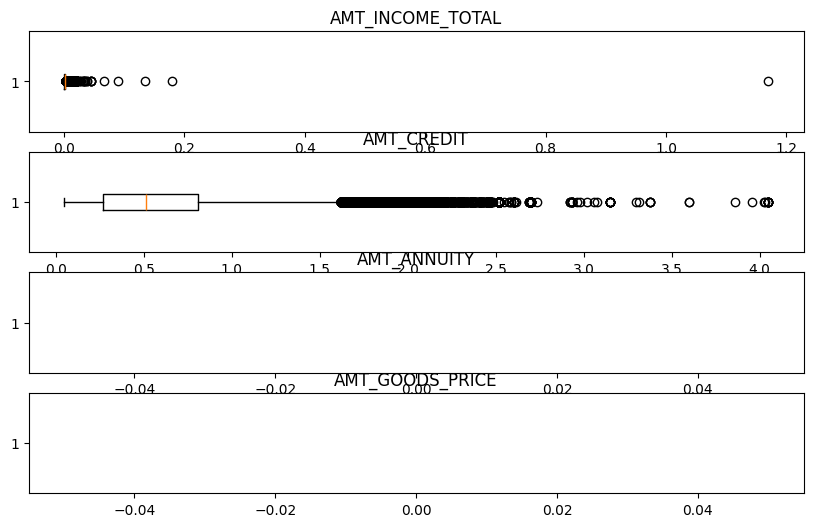

In [ ]:
f, ax = plt.subplots(4, 1, figsize=(10, 6))
col_list = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

for i in range(0, 4):
    ax[i].boxplot(nums[col_list[i]], vert=False)
    ax[i].set_title(col_list[i])
# Boxplot to check for outliers

In [ ]:
def outlier_thresholds(dataframe, variable):
    percentile001 = dataframe[variable].quantile(0.01)
    percentile099 = dataframe[variable].quantile(0.99)
    interpercentile_range = percentile099 - percentile001
    up_limit = percentile099 + 1.5 * interpercentile_range
    low_limit = percentile001 - 1.5 * interpercentile_range
    return up_limit, low_limit
# function calcualting limits

def replace_with_threshold(dataframe, variable):
    up_limit, low_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
# function to clamp the outliers

replace_with_threshold(train, 'AMT_INCOME_TOTAL')
replace_with_threshold(train, 'AMT_CREDIT')
replace_with_threshold(train, 'AMT_ANNUITY')
replace_with_threshold(train, 'AMT_GOODS_PRICE')
# it is a simple fuction decreasing the outlying values to some limit

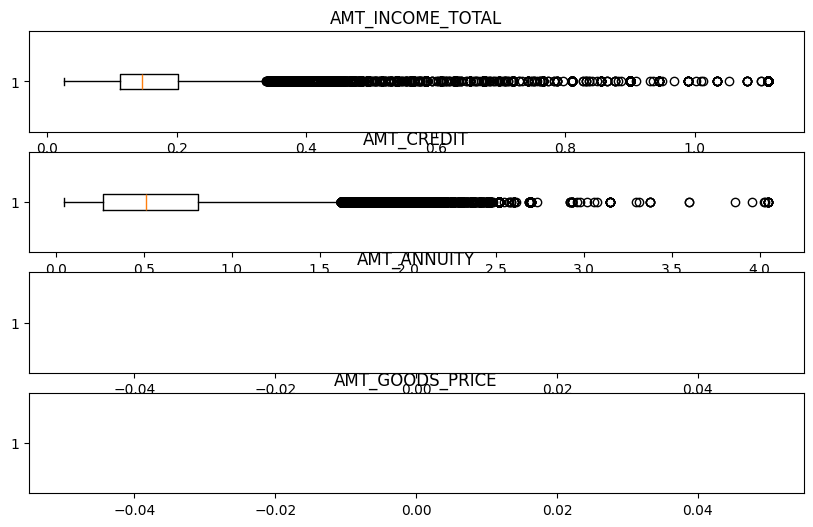

In [ ]:
f, ax = plt.subplots(4, 1, figsize=(10, 6))
col_list = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

for i in range(0, 4):
    ax[i].boxplot(train[col_list[i]], vert=False)
    ax[i].set_title(col_list[i])
# Boxplot to check for outliers

In [ ]:
train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307499.000000,307233.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,306851.000000,246546.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,167946.428454,599025.999706,27101.216345,538396.207429,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,0.514393,0.510853,0.117440,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.08795

In [ ]:
check_DB=(train.DAYS_BIRTH/-365).describe()
print(f'Check DB \n {check_DB}')
check_DE=(train.DAYS_EMPLOYED/-365).describe()
print(f'Check DE \n {check_DE}')
check_DR=(train.DAYS_REGISTRATION/-365).describe()
print(f'Check DR \n {check_DR}')
check_ID=(train.DAYS_ID_PUBLISH/-365).describe()
print(f'Check ID \n {check_ID}')

Check DB 
 count   307511.000000
mean        43.936973
std         11.956133
min         20.517808
25%         34.008219
50%         43.150685
75%         53.923288
max         69.120548
Name: DAYS_BIRTH, dtype: float64
Check DE 
 count   307511.000000
mean      -174.835742
std        387.056895
min      -1000.665753
25%          0.791781
50%          3.323288
75%          7.561644
max         49.073973
Name: DAYS_EMPLOYED, dtype: float64
Check DR 
 count   307511.000000
mean        13.660604
std          9.651743
min         -0.000000
25%          5.506849
50%         12.339726
75%         20.491781
max         67.594521
Name: DAYS_REGISTRATION, dtype: float64
Check ID 
 count   307511.000000
mean         8.203294
std          4.135481
min         -0.000000
25%          4.712329
50%          8.915068
75%         11.778082
max         19.717808
Name: DAYS_ID_PUBLISH, dtype: float64


All ok with days birth, REFISTRATION AND ID_PUBLISH.
I don't know what is wrong with days employed. there is a person with negative 1000 year.


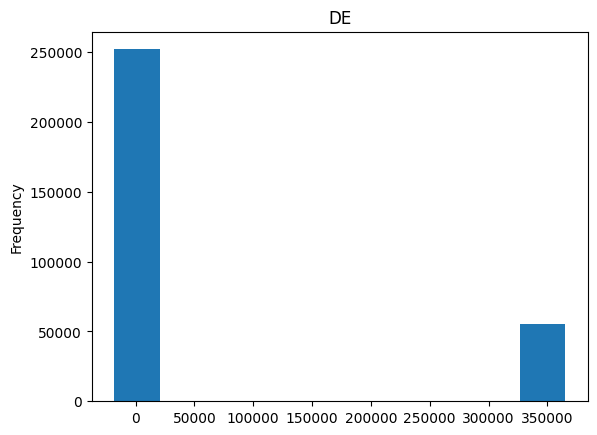

In [ ]:
train['DAYS_EMPLOYED'].plot.hist(title = 'DE');

,DAYS_EMPLOYED
count,252137.000000
mean,6.531971
std,6.406466
min,-0.000000
25%,2.101370
50%,4.515068
75%,8.698630
max,49.073973


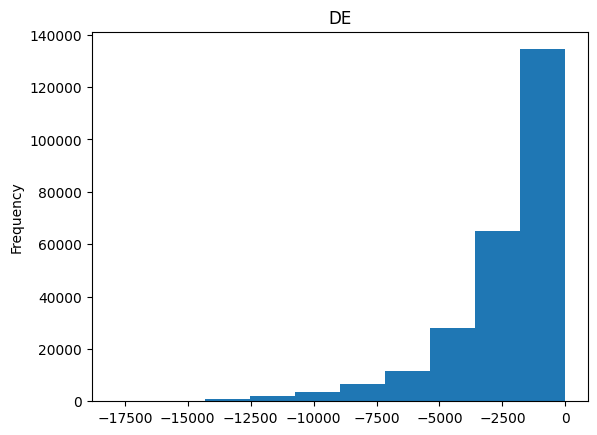

In [ ]:
check_DE2 = train[train['DAYS_EMPLOYED']!=365243]
check_DE2['DAYS_EMPLOYED'].plot.hist(title = 'DE');
(check_DE2['DAYS_EMPLOYED']/-365).describe()

In [ ]:
(test.DAYS_EMPLOYED/-365).describe()

,DAYS_EMPLOYED
count,48744.000000
mean,-184.891415
std,395.475362
min,-1000.665753
25%,0.810959
50%,3.542466
75%,7.972603
max,47.843836


Without 365243 DAYS_EMPLOYED looks ok.
Thus I will change them with nan.
and create new columns with issue indicator.


In [ ]:
test['DE_ANOM'] = test["DAYS_EMPLOYED"] == 365243
train['DE_ANOM'] = train["DAYS_EMPLOYED"] == 365243
train['DAYS_EMPLOYED'] = train['DAYS_EMPLOYED'].replace(365243, np.nan)
test["DAYS_EMPLOYED"] = test["DAYS_EMPLOYED"].replace(365243, np.nan)

Now lets us discover most interesting numeric variables distribution.

In [ ]:
inter_nums=['CNT_CHILDREN','AMT_INCOME_TOTAL', 'AMT_CREDIT',
            'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH',
            'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
            'EXT_SOURCE_1', 'EXT_SOURCE_2','EXT_SOURCE_3']

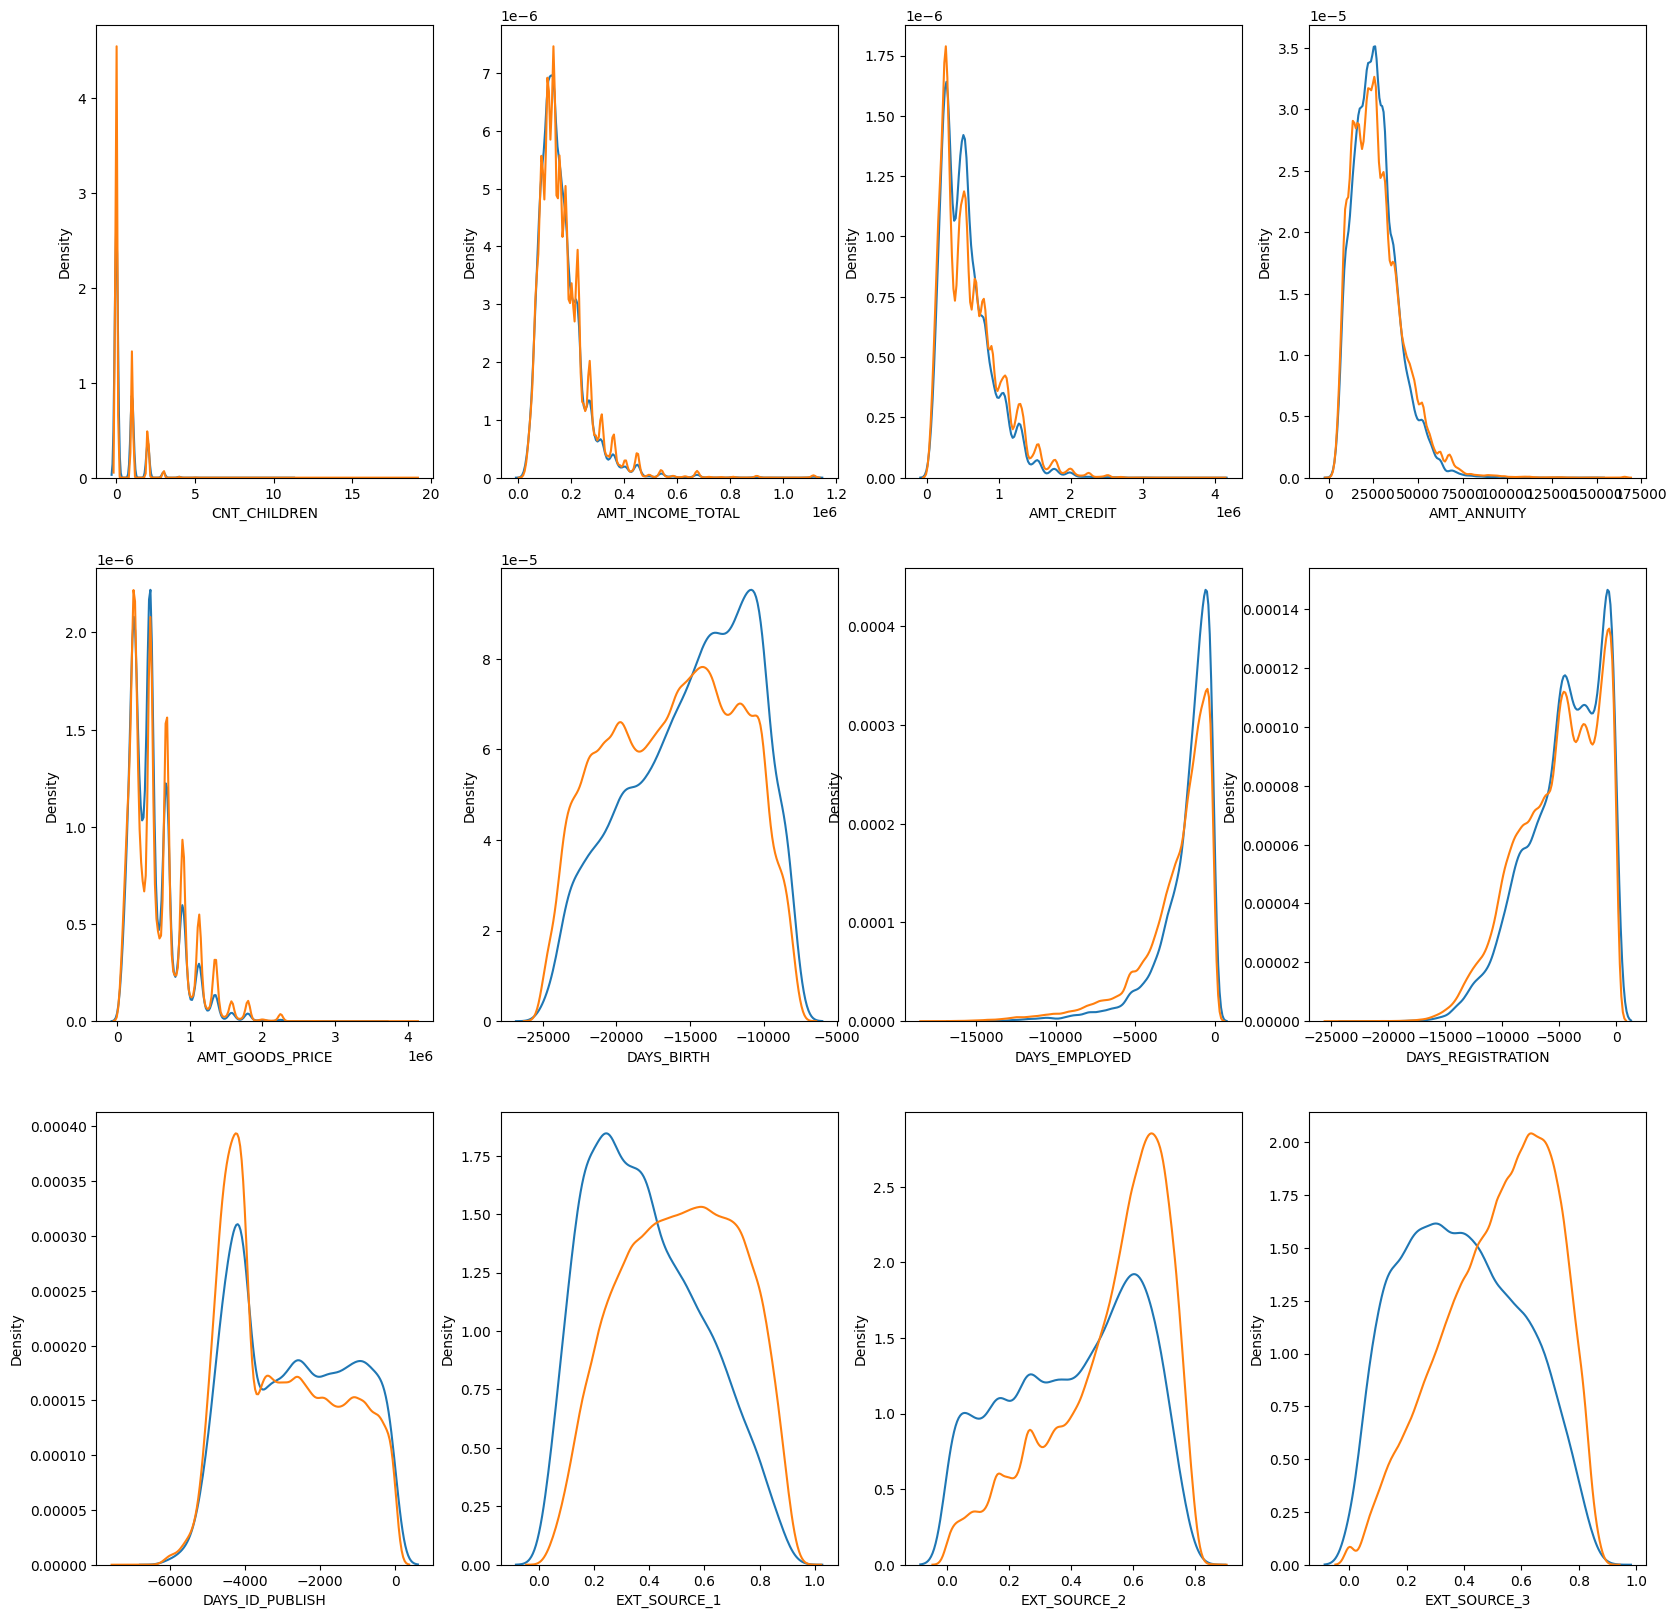

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 20))
axes = axes.flatten()

for i in range(12):
    sns.kdeplot(train.loc[train['TARGET'] == 1, inter_nums[i]], label = 'target == 1',ax=axes[i])
    sns.kdeplot(train.loc[train['TARGET'] == 0, inter_nums[i]], label = 'target == 0',ax=axes[i])

So far, DAYS_BIRTH, 'EXT_SOURCE_1', 'EXT_SOURCE_2','EXT_SOURCE_3' have so skewness depend on target.
I will polynomize them. Also I will do this type of engineering: AMT_CREDIT / AMT_INCOME_TOTAL, AMT_INCOME_TOTAL/CNT_CHILDREN, AMT_ANNUITY / AMT_CREDIT,DAYS_EMPLOYED / DAYS_BIRTH. Probably, their interaction could give more inforation.

## Categorical variables

In [ ]:
cats=train.select_dtypes(include='object')
cats

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,block of flats,Block,No
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,NaN,NaN,NaN,NaN
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,NaN,NaN,NaN,NaN
4,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,Cash loans,M,N,N,Unaccompanied,Working,Secondary / secondary special,Separated,With parents,Sales staff,THURSDAY,Services,reg oper account,block of flats,"Stone, brick",No
307507,Cash loans,F,N,Y,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,NaN,MONDAY,XNA,reg oper account,block of flats,"Stone, brick",No
307508,Cash loans,F,N,Y,Unaccompanied,Working,Higher education,Separated,House / apartment,Managers,THURSDAY,School,reg oper account,block of flats,Panel,No
307509,Cash loans,F,N,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 1,NaN,block of flats,"Stone, brick",No


In [ ]:
cats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 16 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   NAME_CONTRACT_TYPE          307511 non-null  object
 1   CODE_GENDER                 307511 non-null  object
 2   FLAG_OWN_CAR                307511 non-null  object
 3   FLAG_OWN_REALTY             307511 non-null  object
 4   NAME_TYPE_SUITE             306219 non-null  object
 5   NAME_INCOME_TYPE            307511 non-null  object
 6   NAME_EDUCATION_TYPE         307511 non-null  object
 7   NAME_FAMILY_STATUS          307511 non-null  object
 8   NAME_HOUSING_TYPE           307511 non-null  object
 9   OCCUPATION_TYPE             211120 non-null  object
 10  WEEKDAY_APPR_PROCESS_START  307511 non-null  object
 11  ORGANIZATION_TYPE           307511 non-null  object
 12  FONDKAPREMONT_MODE          97216 non-null   object
 13  HOUSETYPE_MODE              1

In [ ]:
cats.describe()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,307511,307511,307511,307511,306219,307511,307511,307511,307511,211120,307511,307511,97216,153214,151170,161756
unique,2,3,2,2,7,8,5,6,6,18,7,58,4,3,7,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,278232,202448,202924,213312,248526,158774,218391,196432,272868,55186,53901,67992,73830,150503,66040,159428


In [ ]:
cats.CODE_GENDER.value_counts()

,count
CODE_GENDER,
F,202448
M,105059
XNA,4


In [ ]:
test.describe(include='object')

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,48744,48744,48744,48744,47833,48744,48744,48744,48744,33139,48744,48744,15947,25125,24851,26535
unique,2,2,2,2,7,7,5,5,6,18,7,58,4,3,7,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,48305,32678,32311,33658,39727,24533,33988,32283,43645,8655,9751,10840,12124,24659,11269,26179


There is no XNA in test's gender columns, so I will drop it from train

In [ ]:
train=train[train['CODE_GENDER']!='XNA']
train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DE_ANOM
0,100002,1,Cash loans,M,N,Y,0,202500.000000,406597.500000,24700.500000,351000.000000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637.000000,-3648.000000,-2120,NaN,1,1,0,1,1,0,Laborers,1.000000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.024700,0.036900,0.972200,0.619200,0.014300,0.000000,0.069000,0.083300,0.125000,0.036900,0.020200,0.019000,0.000000,0.000000,0.025200,0.038300,0.972200,0.634100,0.014400,0.000000,0.069000,0.083300,0.125000,0.037700,0.022000,0.019800,0.000000,0.000000,0.025000,0.036900,0.972200,0.624300,0.014400,0.000000,0.069000,0.083300,0.125000,0.037500,0.020500,0.019300,0.000000,0.000000,reg oper account,block of flats,0.014900,"Stone, brick",No,2.000000,2.000000,2.000000,2.000000,-1134.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,False
1,100003,0,Cash loans,F,N,N,0,270000.000000,1293502.500000,35698.500000,1129500.000000,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188.000000,-1186.000000,-291,NaN,1,1,0,1,1,0,Core staff,2.000000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.095900,0.052900,0.985100,0.796000,0.060500,0.080000,0.034500,0.291700,0.333300,0.013000,0.077300,0.054900,0.003900,0.009800,0.092400,0.053800,0.985100,0.804000,0.049700,0.080600,0.034500,0.291700,0.333300,0.012800,0.079000,0.055400,0.000000,0.000000,0.096800,0.052900,0.985100,0.798700,0.060800,0.080000,0.034500,0.291700,0.333300,0.013200,0.078700,0.055800,0.003900,0.010000,reg oper account,block of flats,0.071400,Block,No,1.000000,0.000000,1.000000,0.000000,-828.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False
2,10

NAME_CONTRACT_TYPE, FLAG_OWN_CAR, FLAG_OWN_REALTY, CODE_GENDER, EMERGENCYSTATE_MODE, HOUSETYPE_MODE will be encoded as dummies. Others will be label encoded. But we need to check their effect on target to check if they matter visually.

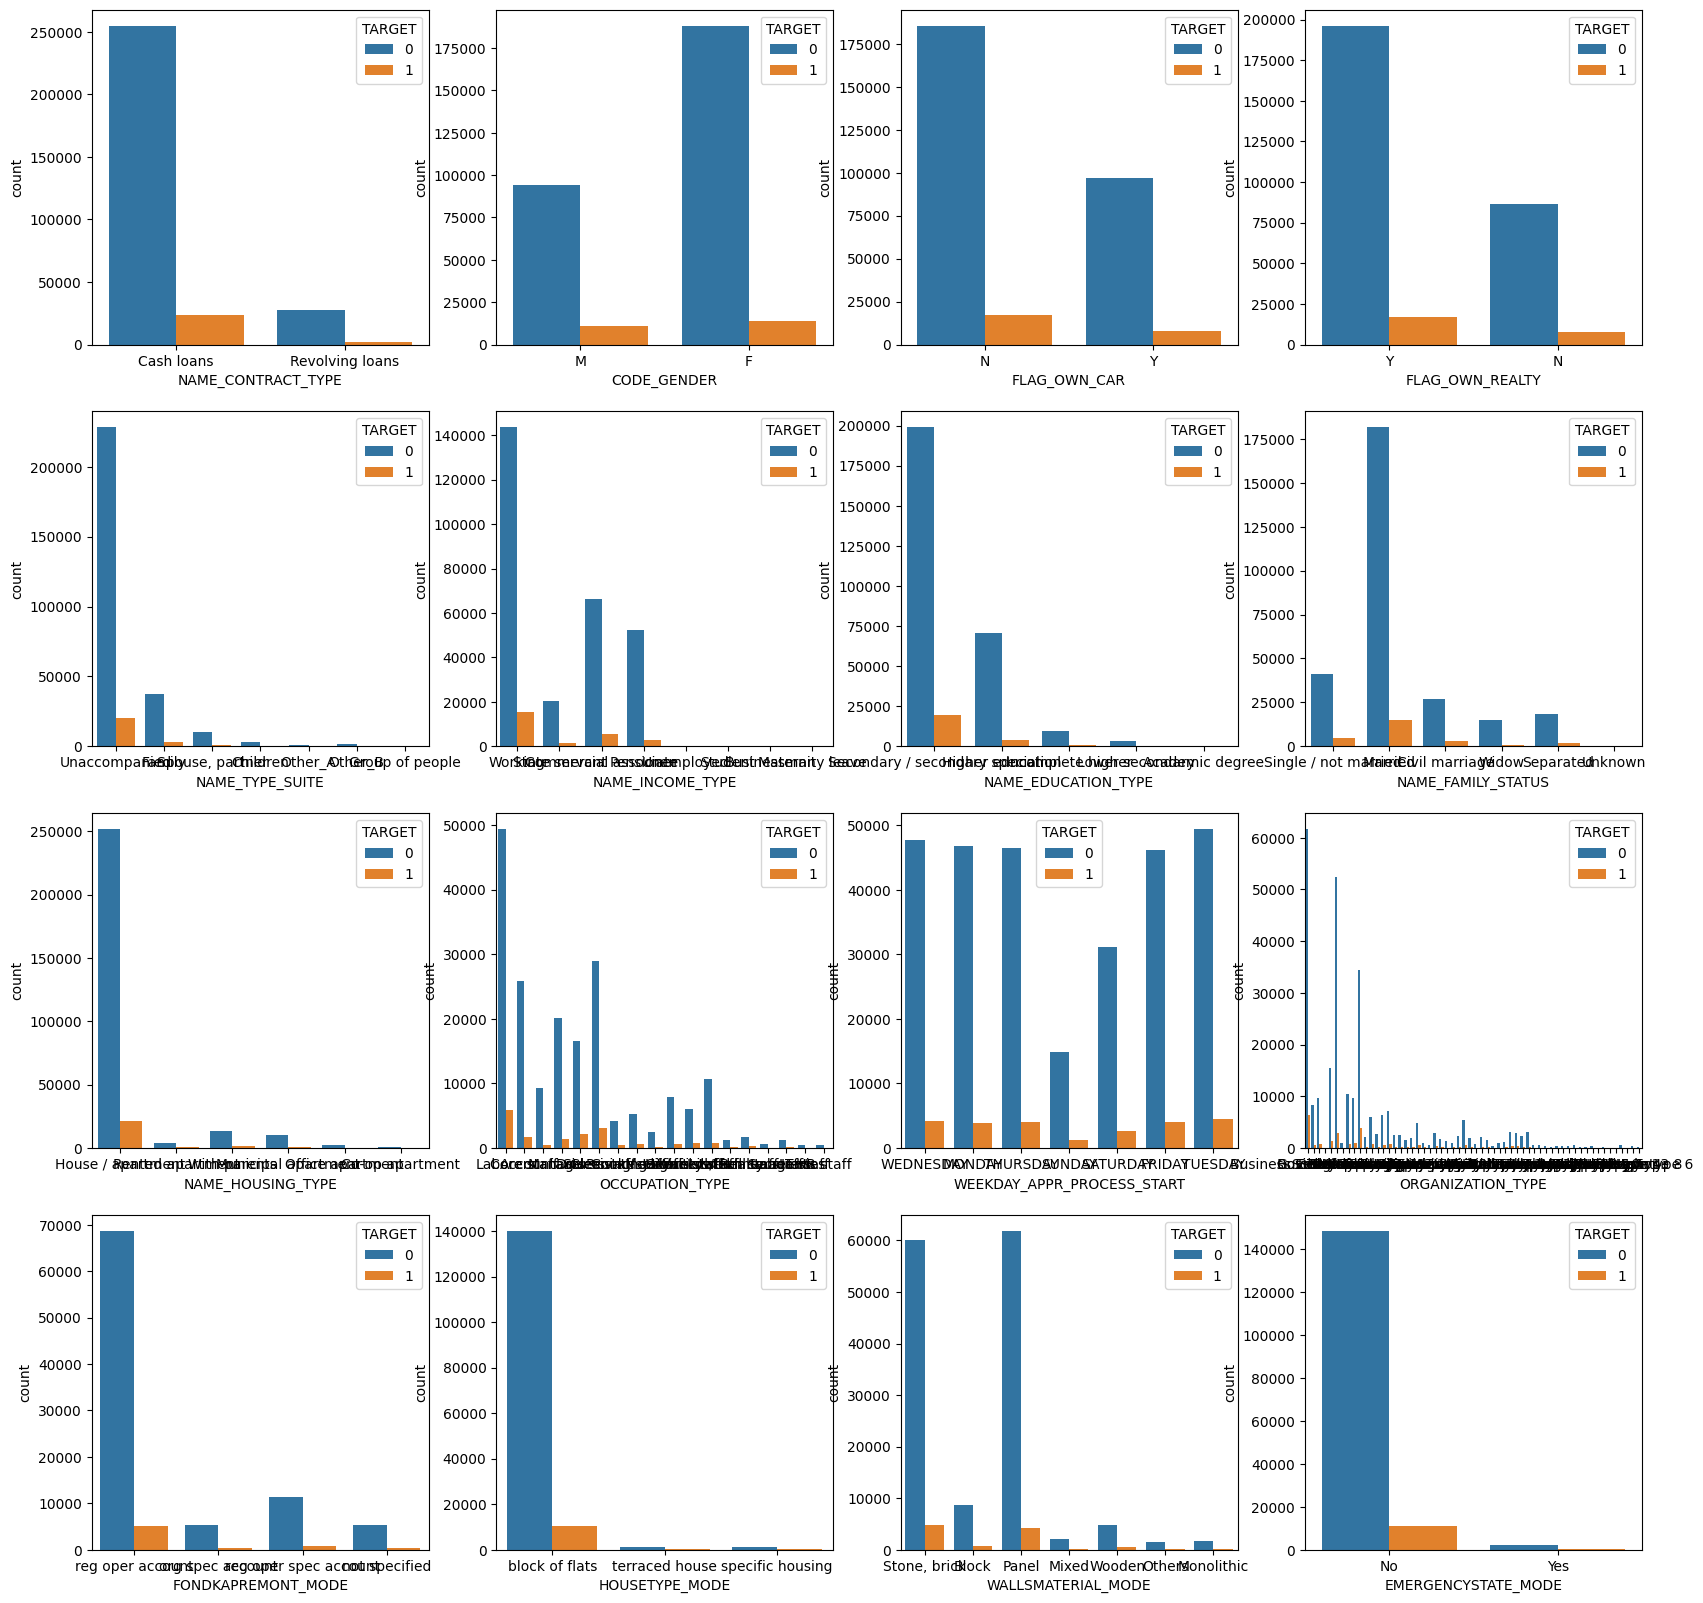

In [ ]:
cats_list = train.select_dtypes(include=['object']).columns

fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for i in range(16):
    sns.countplot(data=train, x=cats_list[i], hue='TARGET', ax=axes[i])

# for col in cats_list:
#     plt.figure(figsize=(10, 5))
#     sns.countplot(data=train, x=col, hue='TARGET'))
#     plt.title(f'Distribution by {col}')
#     plt.xticks(rotation=45)
#     plt.show()


There is a need to normalize the values

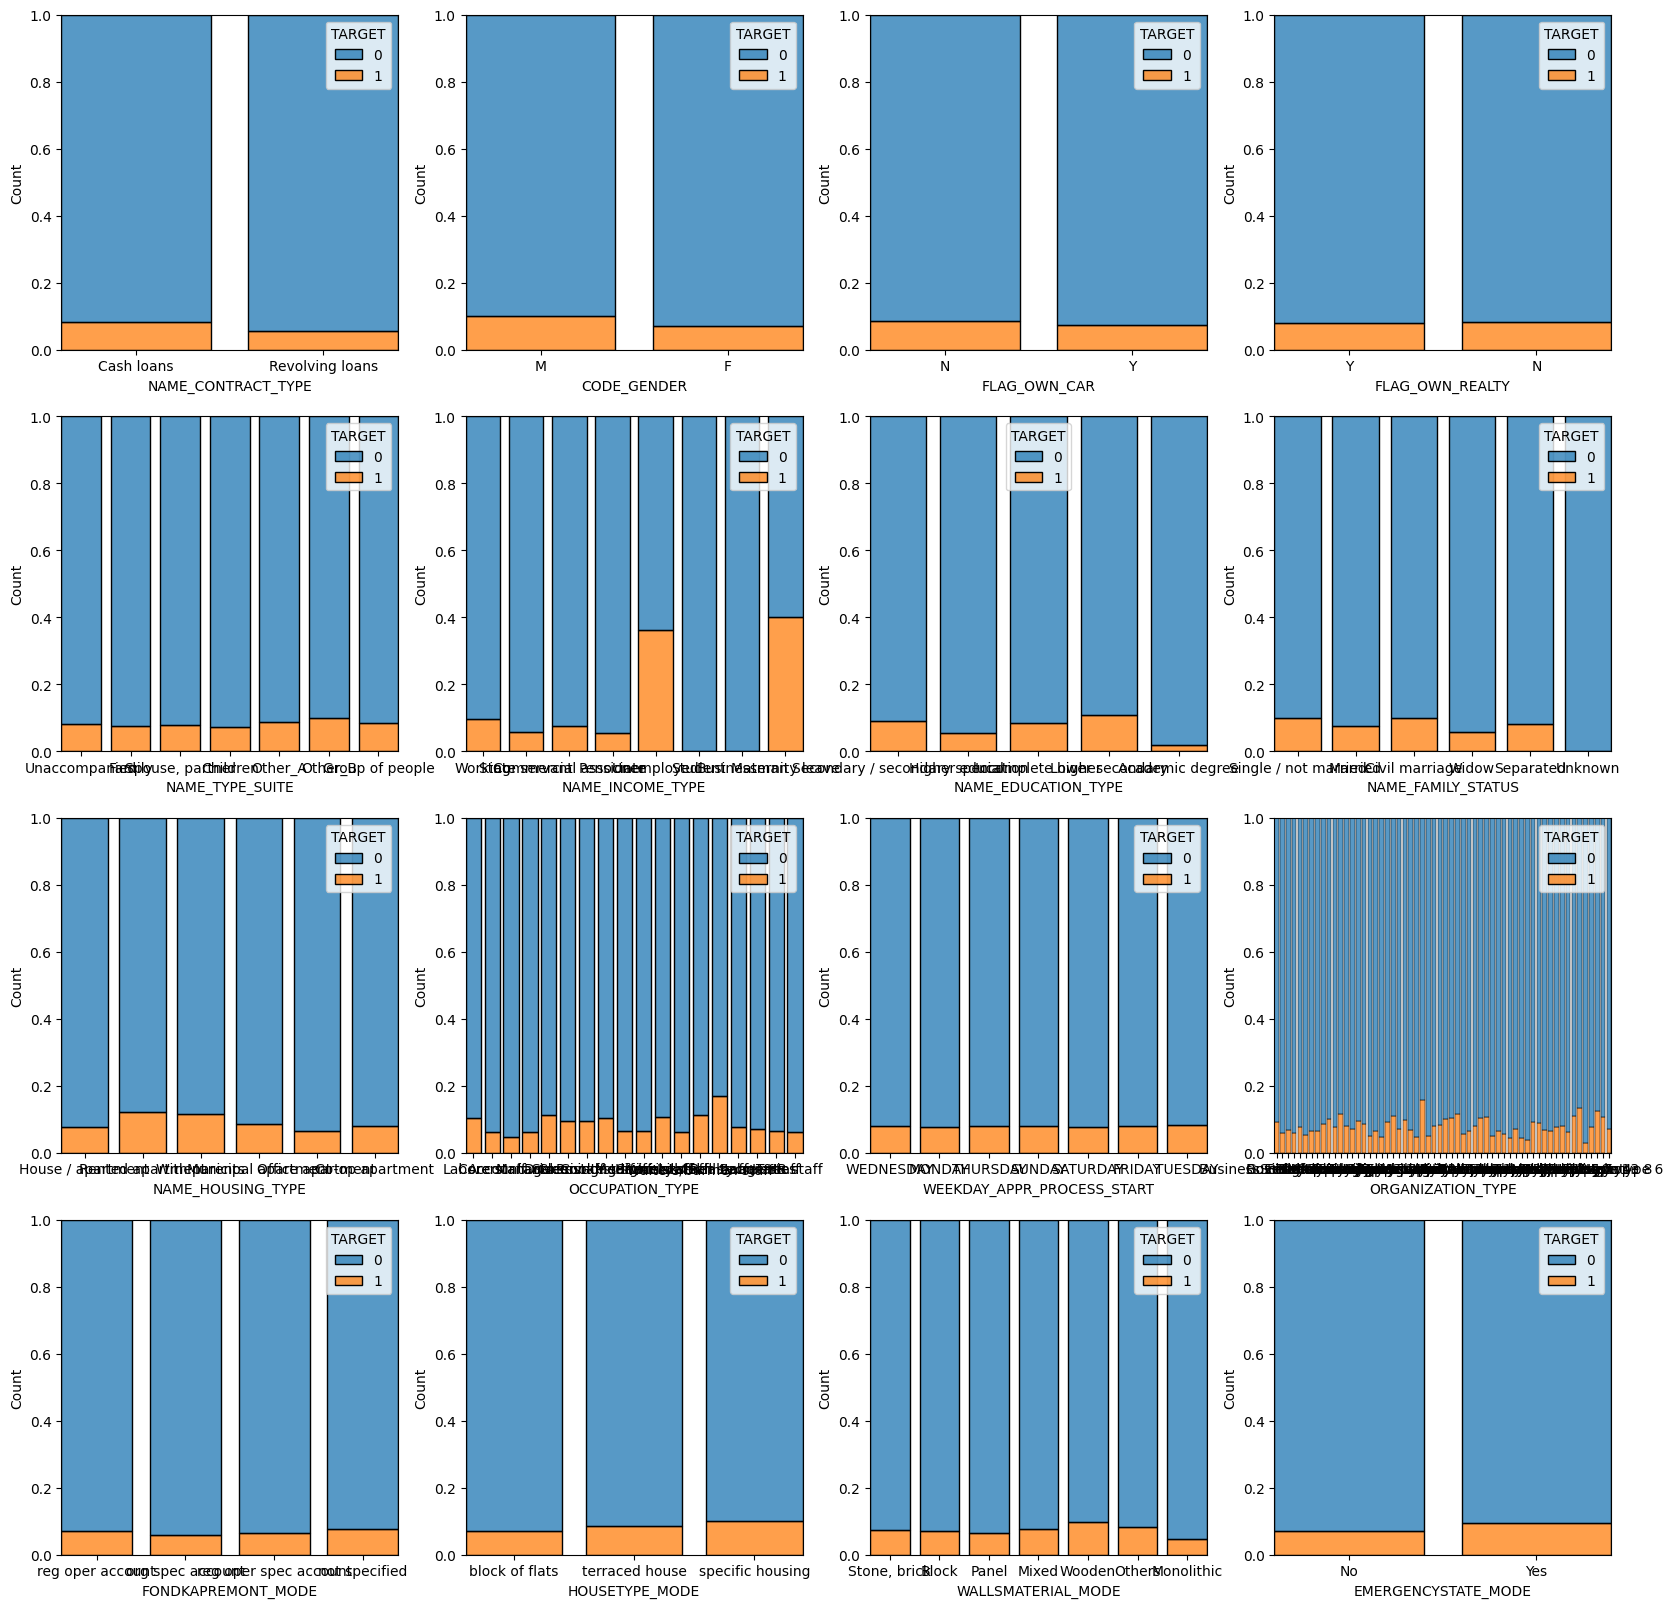

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for i in range(16):
    sns.histplot(data=train.dropna(subset=[cats_list[i], 'TARGET']),
                 x=cats_list[i], hue='TARGET',
                 multiple='fill',shrink=0.8,
                 ax=axes[i])

The only columns I am not sure in is FLAG_OWN_REALITY. But the business understanding says that it should be included. Probably, feature engineering can get better results


In [ ]:
from sklearn.preprocessing import LabelEncoder

def encode_cats(df1, df2):
    df1_encoded = df1.copy()
    df2_encoded = df2.copy()
    label_enc = LabelEncoder()

    cats_list = df1_encoded.select_dtypes(include=['object']).columns

    for col in cats_list:
        unique_count = df1_encoded[col].nunique()

        if unique_count <= 3:
            dummies = pd.get_dummies(df1_encoded[col], prefix=col, drop_first=True)
            df1_encoded = pd.concat([df1_encoded, dummies], axis=1)
            df1_encoded.drop(columns=[col], inplace=True)
            dummies = pd.get_dummies(df2_encoded[col], prefix=col, drop_first=True)
            df2_encoded = pd.concat([df2_encoded, dummies], axis=1)
            df2_encoded.drop(columns=[col], inplace=True)
            print(f"dummied: {col}")

        else:
            df1_encoded[col] = label_enc.fit_transform(df1_encoded[col])
            df2_encoded[col] = label_enc.fit_transform(df2_encoded[col])
            print(f"labeled: {col}")

    return df1_encoded, df2_encoded

train, test = encode_cats(train, test)

dummied: NAME_CONTRACT_TYPE
dummied: CODE_GENDER
dummied: FLAG_OWN_CAR
dummied: FLAG_OWN_REALTY
labeled: NAME_TYPE_SUITE
labeled: NAME_INCOME_TYPE
labeled: NAME_EDUCATION_TYPE
labeled: NAME_FAMILY_STATUS
labeled: NAME_HOUSING_TYPE
labeled: OCCUPATION_TYPE
labeled: WEEKDAY_APPR_PROCESS_START
labeled: ORGANIZATION_TYPE
labeled: FONDKAPREMONT_MODE
dummied: HOUSETYPE_MODE
labeled: WALLSMATERIAL_MODE
dummied: EMERGENCYSTATE_MODE


In [ ]:
train

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DE_ANOM,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,EMERGENCYSTATE_MODE_Yes
0,100002,1,0,202500.000000,406597.500000,24700.500000,351000.000000,6,7,4,3,1,0.018801,-9461,-637.000000,-3648.000000,-2120,NaN,1,1,0,1,1,0,8,1.000000,2,2,6,10,0,0,0,0,0,0,5,0.083037,0.262949,0.139376,0.024700,0.036900,0.972200,0.619200,0.014300,0.000000,0.069000,0.083300,0.125000,0.036900,0.020200,0.019000,0.000000,0.000000,0.025200,0.038300,0.972200,0.634100,0.014400,0.000000,0.069000,0.083300,0.125000,0.037700,0.022000,0.019800,0.000000,0.000000,0.025000,0.036900,0.972200,0.624300,0.014400,0.000000,0.069000,0.083300,0.125000,0.037500,0.020500,0.019300,0.000000,0.000000,2,0.014900,5,2.000000,2.000000,2.000000,2.000000,-1134.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,False,False,True,False,True,False,False,False
1,100003,0,0,270000.000000,1293502.500000,35698.500000,1129500.000000,1,4,1,1,1,0.003541,-16765,-1188.000000,-1186.000000,-291,NaN,1,1,0,1,1,0,3,2.000000,1,1,1,11,0,0,0,0,0,0,39,0.311267,0.622246,NaN,0.095900,0.052900,0.985100,0.796000,0.060500,0.080000,0.034500,0.291700,0.333300,0.013000,0.077300,0.054900,0.003900,0.009800,0.092400,0.053800,0.985100,0.804000,0.049700,0.080600,0.034500,0.291700,0.333300,0.012800,0.079000,0.055400,0.000000,0.000000,0.096800,0.052900,0.985100,0.798700,0.060800,0.080000,0.034500,0.291700,0.333300,0.013200,0.078700,0.055800,0.003900,0.010000,2,0.071400,0,1.000000,0.000000,1.000000,0.000000,-828.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,False,False,False,False,False,False
2,100004,0,0,67500.000000,135000.000000,6750.000000,135000.000000,6,7,4,3,1,0.010032,-19046,-225.000000,-4260.000000,-2531,26.000000,1,1,1,1,1,0,8,1.000000

In [ ]:
test

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DE_ANOM,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,EMERGENCYSTATE_MODE_Yes
0,100001,0,135000.000000,568800.000000,20560.500000,450000.000000,6,6,1,1,1,0.018850,-19241,-2329.000000,-5170.000000,-812,NaN,1,1,0,1,0,1,18,2.000000,2,2,5,18,0,0,0,0,0,0,28,0.752614,0.789654,0.159520,0.066000,0.059000,0.973200,NaN,NaN,NaN,0.137900,0.125000,NaN,NaN,NaN,0.050500,NaN,NaN,0.067200,0.061200,0.973200,NaN,NaN,NaN,0.137900,0.125000,NaN,NaN,NaN,0.052600,NaN,NaN,0.066600,0.059000,0.973200,NaN,NaN,NaN,0.137900,0.125000,NaN,NaN,NaN,0.051400,NaN,NaN,4,0.039200,5,0.000000,0.000000,0.000000,0.000000,-1740.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,False,False,False,False,True,False,False,False
1,100005,0,99000.000000,222768.000000,17370.000000,180000.000000,6,6,4,1,1,0.035792,-18064,-4469.000000,-9118.000000,-1623,NaN,1,1,0,1,0,0,9,2.000000,2,2,0,9,0,0,0,0,0,0,42,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,7,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,False,False,True,False,True,False,False,False
2,100013,0,202500.000000,663264.000000,69777.000000,630000.000000,7,6,1,1,1,0.019101,-20038,-4458.000000,-2175.000000,-3503,5.000000,1,1,0,1,0,0,4,2.000000,2,2,1,14,0,0,0,0,0,0,54,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,7,0.000000,0.000000,0.000000,0.000000,-856.000000,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.00000

# FEATURE ENGINEERING

## New features creation

I am going to start from polynomial types ot the previously mentioned columns.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
imputer = SimpleImputer(strategy='median')

polynoms_pre=['DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2','EXT_SOURCE_3']

poly_train=train[polynoms_pre]
Y_train=train['TARGET']
poly_test=test[polynoms_pre]

poly_train = imputer.fit_transform(poly_train)
poly_test = imputer.transform(poly_test)
poly_transformer = PolynomialFeatures(degree = 3)

poly_transformer.fit(poly_train)

poly_train = poly_transformer.transform(poly_train)
poly_test = poly_transformer.transform(poly_test)

poly_transformer.get_feature_names_out(input_features = ['DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'])[:15]

array(['1', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'DAYS_BIRTH^2', 'DAYS_BIRTH EXT_SOURCE_1',
       'DAYS_BIRTH EXT_SOURCE_2', 'DAYS_BIRTH EXT_SOURCE_3',
       'EXT_SOURCE_1^2', 'EXT_SOURCE_1 EXT_SOURCE_2',
       'EXT_SOURCE_1 EXT_SOURCE_3', 'EXT_SOURCE_2^2',
       'EXT_SOURCE_2 EXT_SOURCE_3', 'EXT_SOURCE_3^2'], dtype=object)

In [ ]:
(poly_transformer.get_feature_names_out(input_features = ['DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'])[:15]).size

15

In [ ]:
poly_train = pd.DataFrame(poly_train,
                             columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2',
                                                                           'EXT_SOURCE_3', 'DAYS_BIRTH']))
poly_test = pd.DataFrame(poly_test,
                                  columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2',
                                                                                'EXT_SOURCE_3', 'DAYS_BIRTH']))

poly_train['SK_ID_CURR'] = train['SK_ID_CURR']
train_poly = pd.merge(train, poly_train, on = 'SK_ID_CURR', how = 'left')

poly_test['SK_ID_CURR'] = test['SK_ID_CURR']
test_poly = pd.merge(test, poly_test, on = 'SK_ID_CURR', how = 'left')

print(train_poly.shape)
print(test_poly.shape)


(307507, 159)
(48744, 158)


Now lets us create logical interaction of columns.

In [ ]:
train_cons = train.copy()
test_cons = test.copy()

train_cons['CREDIT_RATIO'] = train_cons['AMT_CREDIT'] / train_cons['AMT_INCOME_TOTAL']
train_cons['INCOME_PER_CHILD_PLUS']= train_cons['AMT_INCOME_TOTAL'] / (train_cons['CNT_CHILDREN']+1)
train_cons['REPAY_RATE'] = train_cons['AMT_ANNUITY'] / train_cons['AMT_CREDIT']
train_cons['EMPL_RATIO'] = train_cons['DAYS_EMPLOYED'] / train_cons['DAYS_BIRTH']
train_cons['ANNUITY_INCOME'] = train_cons['AMT_ANNUITY'] / train_cons['AMT_INCOME_TOTAL']

test_cons['CREDIT_RATIO'] = test_cons['AMT_CREDIT'] / test_cons['AMT_INCOME_TOTAL']
test_cons['INCOME_PER_CHILD_PLUS']= test_cons['AMT_INCOME_TOTAL'] / (test_cons['CNT_CHILDREN']+1)
test_cons['REPAY_RATE'] = test_cons['AMT_ANNUITY'] / test_cons['AMT_CREDIT']
test_cons['EMPL_RATIO'] = test_cons['DAYS_EMPLOYED'] / test_cons['DAYS_BIRTH']
test_cons['ANNUITY_INCOME'] = train_cons['AMT_ANNUITY'] / test_cons['AMT_INCOME_TOTAL']

In [ ]:
print(train_cons.shape)
print(test_cons.shape)

(307507, 129)
(48744, 128)


In [ ]:
train_cons.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CREDIT_RATIO,INCOME_PER_CHILD_PLUS,REPAY_RATE,EMPL_RATIO,ANNUITY_INCOME
count,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307495.000000,307229.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,252133.000000,307507.000000,307507.000000,104580.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307505.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,134131.000000,306847.000000,246542.000000,151447.000000,127565.000000,157501.000000,103021.000000,92645.000000,143617.000000,152680.000000,154488.000000,98867.000000,124919.000000,97310.000000,153158.000000,93995.000000,137827.000000,151447.000000,127565.000000,157501.000000,103021.000000,92645.000000,143617.000000,152680.000000,154488.000000,98867.000000,124919.000000,97310.000000,153158.000000,93995.000000,137827.000000,151447.000000,127565.000000,157501.000000,103021.000000,92645.000000,143617.000000,152680.000000,154488.000000,98867.000000,124919.000000,97310.000000,153158.000000,93995.000000,137827.000000,307507.000000,159077.000000,307507.000000,306486.000000,306486.000000,306486.000000,306486.000000,307506.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,265988.000000,265988.000000,265988.000000,265988.000000,265988.000000,265988.000000,307507.000000,307507.000000,307495.000000,252133.000000,307495.000000
mean,278181.527256,0.080730,0.417047,167946.183861,599028.596733,27101.309126,538397.724489,5.227198,4.670277,3.188279,1.472321,1.290

## New features evaluation

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    class_weight='balanced'
)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
train_rf = train.drop(columns='TARGET')
test_rf = test
Y_train = train['TARGET']

imputer = SimpleImputer(strategy='median')
scaler = MinMaxScaler(feature_range=(0, 1))

train_rf = imputer.fit_transform(train_rf)
train_rf = scaler.fit_transform(train_rf)
test_rf = imputer.transform(test_rf)
test_rf = scaler.transform(test_rf)

In [ ]:
rf.fit(train_rf, Y_train)

predictions = rf.predict_proba(test_rf)[:, 1]
submit = test[['SK_ID_CURR']]
submit['TARGET'] = predictions

submit.to_csv('rf_baseline.csv', index = False)

Pretty good.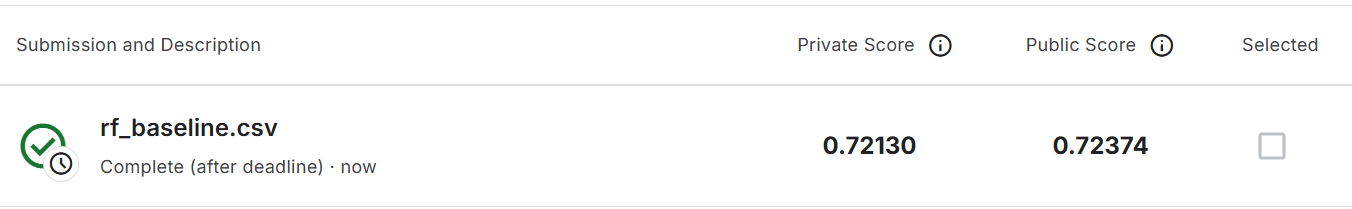

In [ ]:
poly_train_rf = train_poly.drop(columns='TARGET')
poly_test_rf = test_poly
Y_train = train['TARGET']

imputer = SimpleImputer(strategy='median')
scaler = MinMaxScaler(feature_range=(0, 1))

poly_train_rf = imputer.fit_transform(poly_train_rf)
poly_train_rf = scaler.fit_transform(poly_train_rf)
poly_test_rf = imputer.transform(poly_test_rf)
poly_test_rf = scaler.transform(poly_test_rf)

print(poly_train_rf.shape)
print(poly_test_rf.shape)

(307507, 158)
(48744, 158)


In [ ]:
rf.fit(poly_train_rf, Y_train)

predictions = rf.predict_proba(poly_test_rf)[:, 1]

submit = test[['SK_ID_CURR']]
submit['TARGET'] = predictions

submit.to_csv('rf_baseline_poly.csv', index = False)

Polynomic features get worse results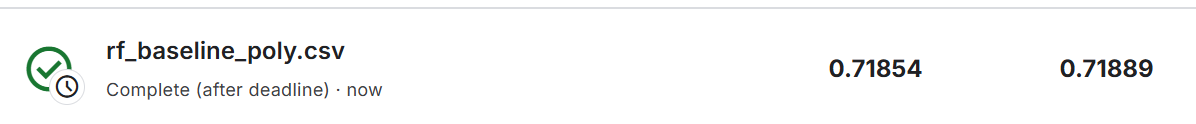

In [ ]:
cons_train_rf = train_cons.drop(columns='TARGET')
cons_test_rf = test_cons
Y_train = train['TARGET']

imputer = SimpleImputer(strategy='median')
scaler = MinMaxScaler(feature_range=(0, 1))

cons_train_rf = imputer.fit_transform(cons_train_rf)
cons_train_rf = scaler.fit_transform(cons_train_rf)
cons_test_rf = imputer.transform(cons_test_rf)
cons_test_rf = scaler.transform(cons_test_rf)

print(cons_train_rf.shape)
print(cons_test_rf.shape)

(307507, 128)
(48744, 128)


In [ ]:
rf.fit(cons_train_rf, Y_train)

predictions = rf.predict_proba(cons_test_rf)[:, 1]

submit = test[['SK_ID_CURR']]
submit['TARGET'] = predictions

submit.to_csv('rf_baseline_cons.csv', index = False)

Feature Construction get better results than baseline.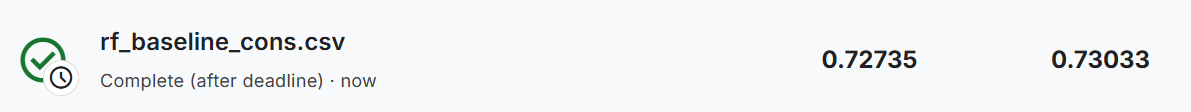

## New data
Now it is a time to merge other data from competition

In [ ]:
def df_inf(df):
  print('df.info()')
  print(df.info())
  print('df.describe()')
  print(df.describe())
  print('df.describe(include=object)')
  print(df.describe(include='object'))
  print('DF counts')
  for i in range(df.shape[1]):
    if df.iloc[:,i].dtypes == 'object':
      print(df.iloc[:,i].value_counts())

In [ ]:
bureau = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/bureau.csv")
bureau

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.000000,-153.000000,NaN,0,91323.000000,0.000000,NaN,0.000000,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.000000,NaN,NaN,0,225000.000000,171342.000000,NaN,0.000000,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.000000,NaN,NaN,0,464323.500000,NaN,NaN,0.000000,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.000000,NaN,NaN,0.000000,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.000000,NaN,77674.500000,0,2700000.000000,NaN,NaN,0.000000,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.000000,NaN,0.000000,0,11250.000000,11250.000000,0.000000,0.000000,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.000000,-2493.000000,5476.500000,0,38130.840000,0.000000,0.000000,0.000000,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.000000,-970.000000,NaN,0,15570.000000,NaN,NaN,0.000000,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.000000,-1513.000000,NaN,0,36000.000000,0.000000,0.000000,0.000000,Consumer credit,-1508,NaN


In [ ]:
df_inf(bureau)

df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB
None
df.describe()
          SK_ID_CURR   SK_ID_BUREAU    DAYS_CREDIT  CREDIT_DAY_OVERDUE  \
count 1716428.000

In [ ]:
bureau_balance = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/bureau_balance.csv")
bureau_balance

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
...,...,...,...
27299920,5041336,-47,X
27299921,5041336,-48,X
27299922,5041336,-49,X
27299923,5041336,-50,X


In [ ]:
df_inf(bureau_balance)

df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB
None
df.describe()
         SK_ID_BUREAU  MONTHS_BALANCE
count 27299925.000000 27299925.000000
mean   6036297.332974      -30.741687
std     492348.856904       23.864509
min    5001709.000000      -96.000000
25%    5730933.000000      -46.000000
50%    6070821.000000      -25.000000
75%    6431951.000000      -11.000000
max    6842888.000000        0.000000
df.describe(include=object)
          STATUS
count   27299925
unique         8
top            C
freq    13646993
DF counts
STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64


In [ ]:
POS_CASH_balance = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/POS_CASH_balance.csv")
POS_CASH_balance

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.000000,45.000000,Active,0,0
1,1715348,367990,-33,36.000000,35.000000,Active,0,0
2,1784872,397406,-32,12.000000,9.000000,Active,0,0
3,1903291,269225,-35,48.000000,42.000000,Active,0,0
4,2341044,334279,-35,36.000000,35.000000,Active,0,0
...,...,...,...,...,...,...,...,...
10001353,2448283,226558,-20,6.000000,0.000000,Active,843,0
10001354,1717234,141565,-19,12.000000,0.000000,Active,602,0
10001355,1283126,315695,-21,10.000000,0.000000,Active,609,0
10001356,1082516,450255,-22,12.000000,0.000000,Active,614,0


In [ ]:
df_inf(POS_CASH_balance)

df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB
None
df.describe()
           SK_ID_PREV      SK_ID_CURR  MONTHS_BALANCE  CNT_INSTALMENT  \
count 10001358.000000 10001358.000000 10001358.000000  9975287.000000   
mean   1903216.598957   278403.863306      -35.012588       17.089650   
std     535846.530722   102763.745090       26.066570       11.995056   
min    1000001.000000   100001.000000      -96.000000        1.000000   
25%    1434405.000000   189550.000000      -54.000000       10.00000

In [ ]:
credit_card_balance = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/credit_card_balance.csv")
credit_card_balance

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970000,135000,0.000000,877.500000,0.000000,877.500000,1700.325000,1800.000000,1800.000000,0.000000,0.000000,0.000000,0.000000,1,0.000000,1.000000,35.000000,Active,0,0
1,2582071,363914,-1,63975.555000,45000,2250.000000,2250.000000,0.000000,0.000000,2250.000000,2250.000000,2250.000000,60175.080000,64875.555000,64875.555000,1.000000,1,0.000000,0.000000,69.000000,Active,0,0
2,1740877,371185,-7,31815.225000,450000,0.000000,0.000000,0.000000,0.000000,2250.000000,2250.000000,2250.000000,26926.425000,31460.085000,31460.085000,0.000000,0,0.000000,0.000000,30.000000,Active,0,0
3,1389973,337855,-4,236572.110000,225000,2250.000000,2250.000000,0.000000,0.000000,11795.760000,11925.000000,11925.000000,224949.285000,233048.970000,233048.970000,1.000000,1,0.000000,0.000000,10.000000,Active,0,0
4,1891521,126868,-1,453919.455000,450000,0.000000,11547.000000,0.000000,11547.000000,22924.890000,27000.000000,27000.000000,443044.395000,453919.455000,453919.455000,0.000000,1,0.000000,1.000000,101.000000,Active,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3840307,1036507,328243,-9,0.000000,45000,NaN,0.000000,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0,NaN,NaN,0.000000,Active,0,0
3840308,1714892,347207,-9,0.000000,45000,0.000000,0.000000,0.000000,0.000000,0.000000,1879.110000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,23.000000,Active,0,0
3840309,1302323,215757,-9,275784.975000,585000,270000.000000,270000.000000,0.000000,0.000000,2250.000000,375750.000000,356994.675000,269356.140000,273093.975000,273093.975000,2.000000,2,0.000000,0.000000,18.000000,Active,0,0
3840310,1624872,430337,-10,0.000000,450000,NaN,0.000000,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0,NaN,NaN,0.000000,Active,0,0


In [ ]:
df_inf(credit_card_balance)

df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALM

In [ ]:
previous_application = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/previous_application.csv")
previous_application

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430000,17145.000000,17145.000000,0.000000,17145.000000,SATURDAY,15,Y,1,0.000000,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.000000,middle,POS mobile with interest,365243.000000,-42.000000,300.000000,-42.000000,-37.000000,0.000000
1,2802425,108129,Cash loans,25188.615000,607500.000000,679671.000000,NaN,607500.000000,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.000000,low_action,Cash X-Sell: low,365243.000000,-134.000000,916.000000,365243.000000,365243.000000,1.000000
2,2523466,122040,Cash loans,15060.735000,112500.000000,136444.500000,NaN,112500.000000,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.000000,high,Cash X-Sell: high,365243.000000,-271.000000,59.000000,365243.000000,365243.000000,1.000000
3,2819243,176158,Cash loans,47041.335000,450000.000000,470790.000000,NaN,450000.000000,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.000000,middle,Cash X-Sell: middle,365243.000000,-482.000000,-152.000000,-182.000000,-177.000000,1.000000
4,1784265,202054,Cash loans,31924.395000,337500.000000,404055.000000,NaN,337500.000000,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.000000,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670209,2300464,352015,Consumer loans,14704.290000,267295.500000,311400.000000,0.000000,267295.500000,WEDNESDAY,12,Y,1,0.000000,NaN,NaN,XAP,Approved,-544,Cash through the bank,XAP,NaN,Refreshed,Furniture,POS,XNA,Stone,43,Furniture,30.000000,low_normal,POS industry with interest,365243.000000,-508.000000,362.000000,-358.000000,-351.000000,0.000000
1670210,2357031,334635,Consumer loans,6622.020000,87750.000000,64291.500000,29250.000000,87750.000000,TUESDAY,15,Y,1,0.340554,NaN,NaN,XAP,Approved,-1694,Cash through the bank,XAP,Unaccompanied,New,Furniture,POS,XNA,Stone,43,Furniture,12.000000,middle,POS industry with interest,365243.000000,-1604.000000,-1274.000000,-1304.000000,-1297.000000,0.000000
1670211,2659632,249544,Consumer loans,11520.855000,105237.000000,102523.500000,10525.500000,105237.000000,MONDAY,12,Y,1,0.101401,NaN,NaN,XAP,Approved,-1488,Cash through the bank,XAP,"Spouse, partner",Repeater,Consumer Electronics,POS,XNA,Country-wide,1370,Consumer electronics,10.000000,low_normal,POS household with interest,365243.000000,-1457.000000,-1187.000000,-1187.000000,-1181.000000,0.000000
1670212,2785582,400317,Cash loans,18821.520000,180000.000000,191880.000000,NaN,180000.000000,WEDNESDAY,9,Y,1,NaN,NaN,NaN,XNA,Approved,-1185,Cash through the bank,XAP,Family,Repeater,XNA,Cash,x-sell,AP+ (Cash loan),-1,XNA,12.000000,low_normal,Cash X-Sell: low,365243.000000,-1155.000000,-825.000000,-825.000000,-817.000000,1.000000


In [ ]:
df_inf(previous_application)

df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774

In [ ]:
installments_payments = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/installments_payments.csv")
installments_payments

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.000000,6,-1180.000000,-1187.000000,6948.360000,6948.360000
1,1330831,151639,0.000000,34,-2156.000000,-2156.000000,1716.525000,1716.525000
2,2085231,193053,2.000000,1,-63.000000,-63.000000,25425.000000,25425.000000
3,2452527,199697,1.000000,3,-2418.000000,-2426.000000,24350.130000,24350.130000
4,2714724,167756,1.000000,2,-1383.000000,-1366.000000,2165.040000,2160.585000
...,...,...,...,...,...,...,...,...
13605396,2186857,428057,0.000000,66,-1624.000000,NaN,67.500000,NaN
13605397,1310347,414406,0.000000,47,-1539.000000,NaN,67.500000,NaN
13605398,1308766,402199,0.000000,43,-7.000000,NaN,43737.435000,NaN
13605399,1062206,409297,0.000000,43,-1986.000000,NaN,67.500000,NaN


In [ ]:
# df_inf(installments_payments)

In [ ]:
def replace_365243(df):
    for col in df.columns:
        if "DAYS" in col:
            df[col] = df[col].replace({365243: np.nan})

    return df


bureau = replace_365243(bureau)
bureau_balance = replace_365243(bureau_balance)
credit_card_balance = replace_365243(credit_card_balance)
POS_CASH_balance = replace_365243(POS_CASH_balance)
previous_application = replace_365243(previous_application)
installments_payments = replace_365243(installments_payments)
# solving the previous problem with 365243

In [ ]:
import pandas as pd

today = pd.Timestamp.today().floor('D')
# lets imagine that the data is fresh

def transform_time_data(df):
    for col in df.columns:
        if "DAYS" in col:
            # changing days variables from int to date
            df[col] = today + pd.to_timedelta(df[col], unit='D')

            # changing months variables from int to date
        elif "MONTHS_BALANCE" in col:
            df[col] = today + pd.to_timedelta(df[col] * 30.44, unit='D')

    return df

# Running the functions on data including test
train = transform_time_data(train)
test = transform_time_data(test)
bureau = transform_time_data(bureau)
bureau_balance = transform_time_data(bureau_balance)
credit_card_balance = transform_time_data(credit_card_balance)
POS_CASH_balance = transform_time_data(POS_CASH_balance)
previous_application = transform_time_data(previous_application)
installments_payments = transform_time_data(installments_payments)

In [ ]:
for col in train:
    if (train[col].dtype != 'object') and (len(train[col].unique()) <= 2):
        print(col)
# checking the booleans for the next part

TARGET
FLAG_MOBIL
FLAG_EMP_PHONE
FLAG_WORK_PHONE
FLAG_CONT_MOBILE
FLAG_PHONE
FLAG_EMAIL
REG_REGION_NOT_LIVE_REGION
REG_REGION_NOT_WORK_REGION
LIVE_REGION_NOT_WORK_REGION
REG_CITY_NOT_LIVE_CITY
REG_CITY_NOT_WORK_CITY
LIVE_CITY_NOT_WORK_CITY
FLAG_DOCUMENT_2
FLAG_DOCUMENT_3
FLAG_DOCUMENT_4
FLAG_DOCUMENT_5
FLAG_DOCUMENT_6
FLAG_DOCUMENT_7
FLAG_DOCUMENT_8
FLAG_DOCUMENT_9
FLAG_DOCUMENT_10
FLAG_DOCUMENT_11
FLAG_DOCUMENT_12
FLAG_DOCUMENT_13
FLAG_DOCUMENT_14
FLAG_DOCUMENT_15
FLAG_DOCUMENT_16
FLAG_DOCUMENT_17
FLAG_DOCUMENT_18
FLAG_DOCUMENT_19
FLAG_DOCUMENT_20
FLAG_DOCUMENT_21
DE_ANOM
NAME_CONTRACT_TYPE_Revolving loans
CODE_GENDER_M
FLAG_OWN_CAR_Y
FLAG_OWN_REALTY_Y
HOUSETYPE_MODE_specific housing
HOUSETYPE_MODE_terraced house
EMERGENCYSTATE_MODE_Yes


## Featuretools

In [ ]:
pip install featuretools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.9/587.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 28.5 MB/s eta 0:00:00


In [ ]:
import featuretools as ft

Y_train = train['TARGET']
train = train.drop(columns='TARGET')
train['set'] = 'train'
test['set'] = 'test'

# temporary concat train and test for featuretools with set
app_all = pd.concat([train, test], axis=0, ignore_index=True)

In [ ]:
previous_types = {}

previous_types['NFLAG_LAST_APPL_IN_DAY']='BooleanNullable'
previous_types['NFLAG_INSURED_ON_APPROVAL']='BooleanNullable'
# highling booleans for ft

In [ ]:
from woodwork.logical_types import Ordinal

rating_order = [-1, 1, 2, 3]

ordinal_rating = Ordinal(order=rating_order)

train_types = {}

for col in train:
    if (train[col].dtype != 'object') and (len(train[col].unique()) <= 2):
        train_types[col] = 'Boolean'

train_types['REGION_RATING_CLIENT'] = ordinal_rating
train_types['REGION_RATING_CLIENT_W_CITY'] = ordinal_rating
train_types['set'] = 'Categorical'
# highlinting categoricals for ft

In [ ]:
es = ft.EntitySet(id = 'ft_data')

# 1. train+test
es = es.add_dataframe(
    dataframe_name='app_all',
    dataframe=app_all,
    index='SK_ID_CURR',
    logical_types=train_types
)

# 3. Bureau
es = es.add_dataframe(
    dataframe_name='bureau',
    dataframe=bureau,
    index='SK_ID_BUREAU',
    time_index='DAYS_CREDIT'
)

# 4. Bureau Balance
es = es.add_dataframe(
    dataframe_name='bureau_balance',
    dataframe=bureau_balance,
    make_index=True,
    index='bureau_balance_index',
    time_index='MONTHS_BALANCE'
)

# 5. POS CASH Balance
es = es.add_dataframe(
    dataframe_name='POS_CASH_balance',
    dataframe=POS_CASH_balance,
    make_index=True,
    index='POS_CASH_balance_index',
    time_index='MONTHS_BALANCE'
)

# 6. Credit Card Balance
es = es.add_dataframe(
    dataframe_name='credit_card_balance',
    dataframe=credit_card_balance,
    make_index=True,
    index='credit_index',
    time_index='MONTHS_BALANCE'
)

# 7. Previous Application
es = es.add_dataframe(
    dataframe_name='previous_application',
    dataframe=previous_application,
    index='SK_ID_PREV',
    time_index='DAYS_DECISION',
    logical_types=previous_types
)

# 8. Installments Payments
es = es.add_dataframe(
    dataframe_name='installments_payments',
    dataframe=installments_payments,
    make_index=True,
    index='installments_index',
    time_index='DAYS_ENTRY_PAYMENT'
)

/usr/local/lib/python3.12/dist-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/usr/local/lib/python3.12/dist-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/usr/local/lib/python3.12/dist-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/usr/local/lib/python3.12/dist-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. 

In [ ]:
# 1. connections to maindata
r_app_bureau = ft.Relationship(es, 'app_all', 'SK_ID_CURR', 'bureau', 'SK_ID_CURR')
r_app_previous = ft.Relationship(es, 'app_all', 'SK_ID_CURR', 'previous_application', 'SK_ID_CURR')

# 2. Bureau details
r_bureau_balance = ft.Relationship(es, 'bureau', 'SK_ID_BUREAU', 'bureau_balance', 'SK_ID_BUREAU')

# 3. Previous Applications deatails
r_previous_cash = ft.Relationship(es, 'previous_application', 'SK_ID_PREV', 'POS_CASH_balance', 'SK_ID_PREV')
r_previous_installments = ft.Relationship(es, 'previous_application', 'SK_ID_PREV', 'installments_payments', 'SK_ID_PREV')
r_previous_credit = ft.Relationship(es, 'previous_application', 'SK_ID_PREV', 'credit_card_balance', 'SK_ID_PREV')

# adding to EntitySet
es = es.add_relationships([
    r_app_bureau,
    r_app_previous,
    r_bureau_balance,
    r_previous_cash,
    r_previous_installments,
    r_previous_credit
])

print(es)

Entityset: ft_data
  DataFrames:
    app_all [Rows: 356251, Columns: 124]
    bureau [Rows: 1716428, Columns: 17]
    bureau_balance [Rows: 27299925, Columns: 4]
    POS_CASH_balance [Rows: 10001358, Columns: 9]
    credit_card_balance [Rows: 3840312, Columns: 24]
    previous_application [Rows: 1670214, Columns: 37]
    installments_payments [Rows: 13605401, Columns: 9]
  Relationships:
    bureau.SK_ID_CURR -> app_all.SK_ID_CURR
    previous_application.SK_ID_CURR -> app_all.SK_ID_CURR
    bureau_balance.SK_ID_BUREAU -> bureau.SK_ID_BUREAU
    POS_CASH_balance.SK_ID_PREV -> previous_application.SK_ID_PREV
    installments_payments.SK_ID_PREV -> previous_application.SK_ID_PREV
    credit_card_balance.SK_ID_PREV -> previous_application.SK_ID_PREV


In [ ]:
import gc

# delete big unneeded data
del bureau_balance, installments_payments, POS_CASH_balance, credit_card_balance
gc.collect() # clean trash

338

In [ ]:
feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name='app_all', # main app
    agg_primitives=['mean', 'max', 'min', 'std', 'sum', 'count','mode', 'trend', 'last'], # aggregation function
    trans_primitives=['day', 'month', 'year'], # transforming dates
    max_depth=2,
    chunk_size=500,
    n_jobs=1,
    verbose=True,
    max_features=500
)

# I have bought the ram from google thus i set big chunk size and etc
# usually people use smaller

/usr/local/lib/python3.12/dist-packages/featuretools/synthesis/dfs.py:321: UnusedPrimitiveWarning: Some specified primitives were not used during DFS:
  trans_primitives: ['day', 'month', 'year']
This may be caused by a using a value of max_depth that is too small, not setting interesting values, or it may indicate no compatible columns for the primitive were found in the data. If the DFS call contained multiple instances of a primitive in the list above, none of them were used.
  warnings.warn(warning_msg, UnusedPrimitiveWarning)


Built 500 features
Elapsed: 35:57 | Progress:  34%|███▎      

/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function max at 0x7a2120329580> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ).agg(to_agg)
/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function sum at 0x7a2120328ea0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  ).agg(to_agg)
/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function std at 0x7a212032a0c0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will b

Elapsed: 1:18:51 | Progress:  41%|████      

/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function mean at 0x7a2120329f80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  ).agg(to_agg)
/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function min at 0x7a21203296c0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  ).agg(to_agg)
/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function std at 0x7a212032a0c0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable wil

...

Elapsed: 2:00:40 | Progress:  72%|███████▏  

/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function mean at 0x7a2120329f80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  ).agg(to_agg)
/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function std at 0x7a212032a0c0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  ).agg(to_agg)
/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function min at 0x7a21203296c0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable wil

Elapsed: 3:02:53 | Progress:  79%|███████▊  

/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function std at 0x7a212032a0c0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  ).agg(to_agg)
/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function min at 0x7a21203296c0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  ).agg(to_agg)
/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function mean at 0x7a2120329f80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will

Elapsed: 3:14:02 | Progress: 100%|██████████


In [ ]:
import numpy as np

# 1. Changing infinits for nan
feature_matrix = feature_matrix.replace([np.inf, -np.inf], np.nan)

# 2. deleting columns where >75% is nan
threshold = 0.75
feature_matrix = feature_matrix.dropna(thresh=len(feature_matrix) * (1 - threshold), axis=1)

print(f"Features after: {feature_matrix.shape[1]}")

Осталось признаков после очистки: 451


In [ ]:
#divide train and test
train_final = feature_matrix[feature_matrix['set'] == 'train'].copy()
test_final = feature_matrix[feature_matrix['set'] == 'test'].copy()

#deleting set
X = train_final.drop(columns=['set'])
X_test = test_final.drop(columns=['set'])

print(f"train shape: {X.shape}")
print(f"test shape: {X_test.shape}")

Размер обучающей выборки: (307507, 450)
Размер тестовой выборки: (48744, 450)


# FEATURE SELECTION

##Importance evaluation

In [ ]:
X

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DE_ANOM,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,EMERGENCYSTATE_MODE_Yes,COUNT(bureau),LAST(bureau.AMT_ANNUITY),LAST(bureau.AMT_CREDIT_MAX_OVERDUE),LAST(bureau.AMT_CREDIT_SUM),LAST(bureau.AMT_CREDIT_SUM_DEBT),LAST(bureau.AMT_CREDIT_SUM_LIMIT),LAST(bureau.AMT_CREDIT_SUM_OVERDUE),LAST(bureau.CNT_CREDIT_PROLONG),LAST(bureau.CREDIT_ACTIVE),LAST(bureau.CREDIT_CURRENCY),LAST(bureau.CREDIT_DAY_OVERDUE),LAST(bureau.CREDIT_TYPE),LAST(bureau.SK_ID_BUREAU),MAX(bureau.AMT_ANNUITY),MAX(bureau.AMT_CREDIT_MAX_OVERDUE),MAX(bureau.AMT_CREDIT_SUM),MAX(bureau.AMT_CREDIT_SUM_DEBT),MAX(bureau.AMT_CREDIT_SUM_LIMIT),MAX(bureau.AMT_CREDIT_SUM_OVERDUE),MAX(bureau.CNT_CREDIT_PROLONG),MAX(bureau.CREDIT_DAY_OVERDUE),MEAN(bureau.AMT_ANNUITY),MEAN(bureau.AMT_CREDIT_MAX_OVERDUE),MEAN(bureau.AMT_CREDIT_SUM),MEAN(bureau.AMT_CREDIT_SUM_DEBT),MEAN(bureau.AMT_CREDIT_SUM_LIMIT),MEAN(bureau.AMT_CREDIT_SUM_OVERDUE),MEAN(bureau.CNT_CREDIT_PROLONG),MEAN(bureau.CREDIT_DAY_OVERDUE),MIN(bureau.AMT_ANNUITY),MIN(bureau.AMT_CREDIT_MAX_OVERDUE),MIN(bureau.AMT_CREDIT_SUM),MIN(bureau.AMT_CREDIT_SUM_DEBT),MIN(bureau.AMT_CREDIT_SUM_LIMIT),MIN(bureau.AMT_CREDIT_SUM_OVERDUE),MIN(bureau.CNT_CREDIT_PROLONG),MIN(bureau.CREDIT_DAY_OVERDUE),MODE(bureau.CREDIT_ACTIVE),MODE(bureau.CREDIT_CURRENCY),MODE(bureau.CREDIT_TYPE),STD(bureau.AMT_ANNUITY),STD(bureau.AMT_CREDIT_MAX_OVERDUE),STD(bureau.AMT_CREDIT_SUM),STD(bureau.AMT_CREDIT_SUM_DEBT),STD(bureau.AMT_CREDIT_SUM_LIMIT),STD(bureau.AMT_CREDIT_SUM_OVERDUE),STD(bureau.CNT_CREDIT_PROLONG),STD(bureau.CREDIT_DAY_OVERDUE),SUM(bureau.AMT_ANNUITY),SUM(bureau.AMT_CREDIT_MAX_OVERDUE),SUM(bureau.AMT_CREDIT_SUM),SUM(bureau.AMT_CREDIT_SUM_DEBT),SUM(bureau.AMT_CREDIT_SUM_LIMIT),SUM(bureau.AMT_CREDIT_SUM_OVERDUE),SUM(bureau.CNT_CREDIT_PROLONG),SUM(bureau.CREDIT_DAY_OVERDUE),TREND(bureau.AMT_CREDIT_SUM_ DAYS_CREDIT),TREND(bureau.AMT_CREDIT_SUM_DEBT_ DAYS_CREDIT),TREND(bureau.AMT_CREDI

In [ ]:
import re

# correcting the columns names
X.columns = [re.sub(r'[\[\]<>,:"]', '_', col) for col in X.columns]
X_test.columns = [re.sub(r'[\[\]<>,:"]', '_', col) for col in X_test.columns]

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score

model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    device='gpu'
)

scores = cross_val_score(model, X, Y_train, cv=3, scoring='roc_auc')

print(f"AVG ROC-AUC on cross validation: {scores.mean():.4f} (+/- {scores.std():.4f})")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 16550, number of negative: 188454
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 71685
[LightGBM] [Info] Number of data points in the train set: 205004, number of used features: 445
[LightGBM] [Info] Using GPU Device: NVIDIA L4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 249 dense feature groups (49.27 MB) transferred to GPU in 0.018434 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432468
[LightGBM] [Info] Start training from score -2.432468
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 16550, number of negative: 188455
[LightGBM] [Info] This is the GPU trainer!!


In [ ]:
model.fit(X, Y_train)

predictions = model.predict_proba(X_test)[:,1]

submission = pd.DataFrame({
    'SK_ID_CURR': X_test.index,
    'TARGET': predictions
})

submission.to_csv('gbm_rt.csv', index = False)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 24825, number of negative: 282682
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 71747
[LightGBM] [Info] Number of data points in the train set: 307507, number of used features: 446
[LightGBM] [Info] Using GPU Device: NVIDIA L4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 249 dense feature groups (73.90 MB) transferred to GPU in 0.026154 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432471
[LightGBM] [Info] Start training from score -2.432471


In [ ]:
importances = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
print(importances.sort_values('importance', ascending=False).head(10))

                                               feature  importance
33                                        EXT_SOURCE_3         646
32                                        EXT_SOURCE_2         602
31                                        EXT_SOURCE_1         588
3                                          AMT_ANNUITY         463
2                                           AMT_CREDIT         373
129                          LAST(bureau.SK_ID_BUREAU)         358
287      LAST(POS_CASH_balance.POS_CASH_balance_index)         333
340             MIN(installments_payments.AMT_PAYMENT)         325
207     LAST(previous_application.PRODUCT_COMBINATION)         298
356  TREND(installments_payments.NUM_INSTALMENT_NUM...         295


## Droping the features with zero importance

In [ ]:
zero_features = list(importances[importances['importance'] == 0.0]['feature'])
print('There are %d features with 0.0 importance' % len(zero_features))
importances.tail()

There are 41 features with 0.0 importance


,feature,importance
445,SUM(credit_card_balance.SK_DPD),12
446,SUM(credit_card_balance.SK_DPD_DEF),6
447,SUM(credit_card_balance.SK_ID_CURR),43
448,TREND(credit_card_balance.AMT_BALANCE_ MONTHS_...,77
449,TREND(credit_card_balance.AMT_CREDIT_LIMIT_ACT...,53


In [ ]:
zero_features

['FLAG_MOBIL',
 'FLAG_CONT_MOBILE',
 'FLAG_EMAIL',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'HOUSETYPE_MODE_terraced house',
 'LAST(bureau.CREDIT_CURRENCY)',
 'MIN(bureau.AMT_CREDIT_SUM_OVERDUE)',
 'MIN(bureau.CNT_CREDIT_PROLONG)',
 'MIN(bureau.CREDIT_DAY_OVERDUE)',
 'MODE(bureau.CREDIT_CURRENCY)',
 'SUM(bureau.CNT_CREDIT_PROLONG)',
 'LAST(previous_application.FLAG_LAST_APPL_PER_CONTRACT)',
 'LAST(previous_application.NAME_CONTRACT_TYPE)',
 'LAST(previous_application.NAME_PAYMENT_TYPE)',
 'LAST(previous_application.NAME_PORTFOLIO)',
 'LAST(previous_application.NFLAG_LAST_APPL_IN_DAY)',
 'MIN(POS_CASH_balance.SK_DPD)',
 'MIN(POS_CASH_balance.SK_DPD_DEF)',
 'MODE(POS_CASH_balance.NAME_CONTRACT_STATUS)',
 'STD(POS_CASH_balance.SK_ID_CURR)',
 'TREND(POS_CASH_balance.SK_ID_CURR_ MONTHS_BALANCE)',
 'MIN(installments_payments.NUM_INSTALMENT_NUMBER)',

In [ ]:
X = X.drop(columns = zero_features)
X_test = X_test.drop(columns = zero_features)

In [ ]:
model.fit(X, Y_train)
predictions = model.predict_proba(X_test)[:,1]

submission = pd.DataFrame({
    'SK_ID_CURR': X_test.index,
    'TARGET': predictions
})

submission.to_csv('gbm_rt_big.csv', index = False)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 24825, number of negative: 282682
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 70476
[LightGBM] [Info] Number of data points in the train set: 307507, number of used features: 409
[LightGBM] [Info] Using GPU Device: NVIDIA L4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 246 dense feature groups (72.73 MB) transferred to GPU in 0.035917 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432471
[LightGBM] [Info] Start training from score -2.432471


## Dropping the features out of 95% importance

In [ ]:
importances2=importances.sort_values('importance', ascending = False).reset_index()
importances2['importance_normalized'] = importances2['importance'] / importances2['importance'].sum()
importances2['cumulative_importance'] = np.cumsum(importances2['importance_normalized'])
importances2

,index,feature,importance,importance_normalized,cumulative_importance
0,33,EXT_SOURCE_3,646,0.021533,0.021533
1,32,EXT_SOURCE_2,602,0.020067,0.041600
2,31,EXT_SOURCE_1,588,0.019600,0.061200
3,3,AMT_ANNUITY,463,0.015433,0.076633
4,2,AMT_CREDIT,373,0.012433,0.089067
...,...,...,...,...,...
445,15,FLAG_CONT_MOBILE,0,0.000000,1.000000
446,412,MIN(credit_card_balance.SK_DPD_DEF),0,0.000000,1.000000
447,411,MIN(credit_card_balance.SK_DPD),0,0.000000,1.000000
448,414,MODE(credit_card_balance.NAME_CONTRACT_STATUS),0,0.000000,1.000000


In [ ]:
features_to_keep = list(importances2[importances2['cumulative_importance'] < threshold]['feature'])

train_small = X[features_to_keep]
test_small = X_test[features_to_keep]

In [ ]:
model.fit(train_small, Y_train)
predictions = model.predict_proba(test_small)[:,1]

submission = pd.DataFrame({
    'SK_ID_CURR': X_test.index,
    'TARGET': predictions
})

submission.to_csv('gbm_rt_small.csv', index = False)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 24825, number of negative: 282682
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 32058
[LightGBM] [Info] Number of data points in the train set: 307507, number of used features: 140
[LightGBM] [Info] Using GPU Device: NVIDIA L4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 132 dense feature groups (38.71 MB) transferred to GPU in 0.022842 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432471
[LightGBM] [Info] Start training from score -2.432471


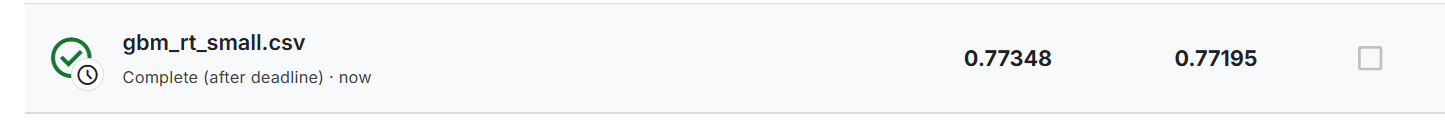

So far the best results is when nothing is dropped. It is very strange and I am going to save the one without zero importance columns.

# Model

##Model tuning

In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. main fuction
def objective(trial):
    # LightGBM
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 50, 500),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.05, 0.5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'device': 'gpu',
        'random_state': 42,
        'n_jobs': -1
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    # i use 3 cross val, because do not want waste time and ram
    score = cross_val_score(LGBMClassifier(**param), X, Y_train, cv=cv, scoring='roc_auc').mean()
    return score

# 2. optimizeing with optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # 30 tryes is enought for pet projects

print("best ROC-AUC:", study.best_value)
print("best params:", study.best_params)

[I 2026-04-05 20:05:21,177] A new study created in memory with name: no-name-e7859c8e-889a-4717-b935-7ebaf7d07fab
[I 2026-04-05 20:06:50,375] Trial 0 finished with value: 0.7818046111985396 and parameters: {'learning_rate': 0.01972455686719493, 'num_leaves': 46, 'max_depth': 4, 'min_child_samples': 276, 'reg_alpha': 0.24435331271249203, 'reg_lambda': 5.243262887032834, 'colsample_bytree': 0.30112489773803114, 'subsample': 0.6647086080270859}. Best is trial 0 with value: 0.7818046111985396.
[I 2026-04-05 20:09:23,582] Trial 1 finished with value: 0.7795904010424252 and parameters: {'learning_rate': 0.006953947808048162, 'num_leaves': 44, 'max_depth': 6, 'min_child_samples': 399, 'reg_alpha': 0.0034910153098856697, 'reg_lambda': 5.490124340579011, 'colsample_bytree': 0.4567761951739957, 'subsample': 0.6676497779598822}. Best is trial 0 with value: 0.7818046111985396.
[I 2026-04-05 20:11:15,933] Trial 2 finished with value: 0.7819185800228801 and parameters: {'learning_rate': 0.0144221594

Лучший ROC-AUC: 0.7837150643756775
Лучшие параметры: {'learning_rate': 0.01638529812050407, 'num_leaves': 48, 'max_depth': 9, 'min_child_samples': 313, 'reg_alpha': 0.0011262252097259228, 'reg_lambda': 9.007541709964453, 'colsample_bytree': 0.16360469030030944, 'subsample': 0.8003635804920852}


In [ ]:
final_params = study.best_params.copy()

# adding the params that were not used in optuna
final_params.update({
    'objective': 'binary',
    'metric': 'auc',
    'device': 'gpu',      # gru from google
    'n_jobs': -1,         # all cpu cores
    'importance_type': 'gain',
    'verbosity': -1
})

# higher for cross validation
if 'n_estimators' not in final_params:
    final_params['n_estimators'] = 3000

print("Final params are ready!")

Финальные параметры готовы к обучению!


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import gc

X_test = X_test[X.columns]

# preparing data  categorical columns
cat_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

for col in cat_features:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# best params from optuna
final_params = study.best_params.copy()

final_params.update({
    'objective': 'binary',
    'metric': 'auc',
    'device': 'gpu',
    'n_jobs': -1,
    'importance_type': 'gain',
    'verbosity': -1,
    'random_state': 42
})

# increasing the three amount
if 'n_estimators' not in final_params or final_params['n_estimators'] < 2000:
    final_params['n_estimators'] = 5000

# fie cross validation
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_preds = np.zeros(len(X_test))
oof_preds = np.zeros(len(X))

for fold_, (trn_idx, val_idx) in enumerate(folds.split(X, Y_train)):
    print(f"\n>>> FOLD {fold_ + 1} <<<")

    X_trn, y_trn = X.iloc[trn_idx], Y_train.iloc[trn_idx]
    X_val, y_val = X.iloc[val_idx], Y_train.iloc[val_idx]

    model = LGBMClassifier(**final_params)

    model.fit(
        X_trn, y_trn,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        categorical_feature=cat_features,
        callbacks=[
            lgb.early_stopping(stopping_rounds=150),
            lgb.log_evaluation(period=100)
        ]
    )

    # collecting the predictions
    test_preds += model.predict_proba(X_test)[:, 1] / folds.n_splits
    # saving the off
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    # clean cash and storage
    del X_trn, X_val, y_trn, y_val
    gc.collect()


Подготовка данных...
Начинаем обучение ансамбля на 438 признаках...

>>> ФОЛД 1 <<<
Training until validation scores don't improve for 150 rounds
[100]	valid_0's auc: 0.759482
[200]	valid_0's auc: 0.766059
[300]	valid_0's auc: 0.769354
[400]	valid_0's auc: 0.771584
[500]	valid_0's auc: 0.773187
[600]	valid_0's auc: 0.774341
[700]	valid_0's auc: 0.77519
[800]	valid_0's auc: 0.775618
[900]	valid_0's auc: 0.775982
[1000]	valid_0's auc: 0.776242
[1100]	valid_0's auc: 0.776574
[1200]	valid_0's auc: 0.776814
[1300]	valid_0's auc: 0.776821
[1400]	valid_0's auc: 0.776912
[1500]	valid_0's auc: 0.776886
Early stopping, best iteration is:
[1431]	valid_0's auc: 0.776985

>>> ФОЛД 2 <<<
Training until validation scores don't improve for 150 rounds
[100]	valid_0's auc: 0.765845
[200]	valid_0's auc: 0.773447
[300]	valid_0's auc: 0.77794
[400]	valid_0's auc: 0.780455
[500]	valid_0's auc: 0.782342
[600]	valid_0's auc: 0.783413
[700]	valid_0's auc: 0.784454
[800]	valid_0's auc: 0.785349
[900]	valid_0's 

In [ ]:

# Kaggle results saving
total_auc = roc_auc_score(Y_train, oof_preds)
print(f"FINAL OOF ROC-AUC: {total_auc:.5f}")

submission = pd.DataFrame({
    'SK_ID_CURR': X_test.index,
    'TARGET': test_preds
})


# results for kaggle
submission['SK_ID_CURR'] = submission['SK_ID_CURR'].astype(int)
file_name = f'submission_final.csv'
submission.to_csv(file_name, index=False)


ИТОГОВЫЙ OOF ROC-AUC: 0.78146
Файл submission_final_auc_0.7815.csv готов к отправке!


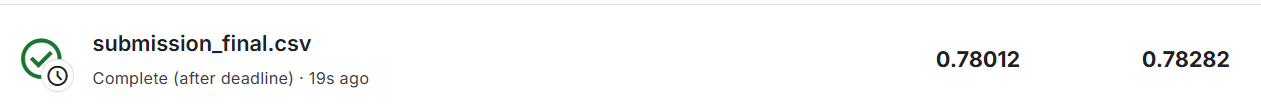